<a href="https://colab.research.google.com/github/GripenNG/signals/blob/main/9_dual_pol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Pol Weather Radar
Companion notebook for my video on **Dual-Pol Weather Radar**. This is a really awesome concept and a massive upgrade for weather radar systems so it's important to know how they work.

This notebook includes:

- field plotting for reflectivity, velocity, ZDR, rhoHV, PhiDP, and spectrum width
- a simple rhoHV/data-quality mask
- a from-scratch PhiDP to KDP estimate
- rough rain-rate estimates from Z and KDP
- a toy hydrometeor/target-type classifier

> Provided as supplemental material for [Marshall Bruner](https://tinyurl.com/marshall-bruner-yt)'s [animated introduction to dual-pol weather radar](https://tinyurl.com/dual-pol-video).

- [GitHub](https://tinyurl.com/github-nb)
- [YouTube](https://tinyurl.com/marshall-bruner-yt-nb)

![thumbnail](https://drive.google.com/uc?id=1hxuk626eZ-GiahOiUgVzQ9Z7szoh-p6f)

In [ ]:
!pip install boto3 arm_pyart

INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/

## Setup

In [ ]:
import datetime as dt
from pathlib import Path

import boto3
from botocore import UNSIGNED
from botocore.config import Config
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import pyart

%matplotlib inline
plt.style.use("ggplot")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



## Choose a Case

This default case matches the [video](https://tinyurl.com/dual-pol-video):

`KTLX20240507_023811_V06`

That volume is from the Oklahoma City NEXRAD radar during a severe-weather event, so the dual-pol fields have useful structure.

In [ ]:
radar_site = "KTLX"
target_time = dt.datetime(2024, 5, 7, 2, 38, tzinfo=dt.timezone.utc)

data_dir = Path("data/nexrad")
data_dir.mkdir(parents=True, exist_ok=True)

max_minutes_from_target = 20

## Pull a NEXRAD Volume from S3

In [ ]:
NEXRAD_BUCKET = "unidata-nexrad-level2"


def s3_client():
    return boto3.client("s3", config=Config(signature_version=UNSIGNED))


def list_nexrad_keys(site, date, bucket=NEXRAD_BUCKET):
    prefix = f"{date:%Y/%m/%d}/{site}/"
    client = s3_client()
    paginator = client.get_paginator("list_objects_v2")

    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if not key.endswith("_MDM"):
                keys.append(key)

    return sorted(keys)


def key_time(key):
    name = Path(key).name
    stamp = name.split("_V")[0].split(".")[0]
    return dt.datetime.strptime(stamp[-15:], "%Y%m%d_%H%M%S").replace(
        tzinfo=dt.timezone.utc
    )


def closest_nexrad_key(site, target, max_minutes=20):
    keys = list_nexrad_keys(site, target.date())
    if not keys:
        raise FileNotFoundError(
            f"No NEXRAD files found for {site} on {target:%Y-%m-%d}"
        )

    best = min(keys, key=lambda key: abs(key_time(key) - target))
    delta_min = abs(key_time(best) - target).total_seconds() / 60

    if delta_min > max_minutes:
        raise RuntimeError(
            f"Closest file is {delta_min:.1f} minutes from target. Increase max_minutes if that is OK."
        )

    return best


def download_nexrad_key(key, out_dir=data_dir, bucket=NEXRAD_BUCKET):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / Path(key).name

    if out_path.exists():
        print(f"Using cached file: {out_path}")
        return out_path

    print(f"Downloading s3://{bucket}/{key}")
    s3_client().download_file(bucket, key, str(out_path))
    return out_path

In [ ]:
key = closest_nexrad_key(radar_site, target_time, max_minutes=max_minutes_from_target)
radar_file = download_nexrad_key(key)

print(key)
print(radar_file)

2024/05/07/KTLX/KTLX20240507_023811_V06
data/nexrad/KTLX20240507_023811_V06


## Read the Volume

Level 2 is the native polar radar data. A volume contains multiple sweeps, usually at increasing elevation angles.

In [ ]:
radar = pyart.io.read_nexrad_archive(str(radar_file))

print(f"Radar: {radar.metadata.get('instrument_name', radar_site)}")
print(f"Scan type: {radar.scan_type}")
print(f"Sweeps: {radar.nsweeps}")
print(f"Fixed angles: {np.round(radar.fixed_angle['data'], 2)} deg")
print("Fields:")
for field in radar.fields:
    print(f"  - {field}")

Radar: KTLX
Scan type: ppi
Sweeps: 23
Fixed angles: [ 0.48  0.48  0.88  0.88  0.48  0.48  1.32  1.32  1.8   0.48  0.48  2.42
  3.12  4.    5.1   6.42  0.48  0.48  8.   10.02 12.48 15.6  19.51] deg
Fields:
  - reflectivity
  - velocity
  - clutter_filter_power_removed
  - cross_correlation_ratio
  - differential_reflectivity
  - spectrum_width
  - differential_phase


## Plot the Main Products

The main dual-pol variables in this video are:

- `reflectivity`: returned power after range correction/calibration
- `velocity`: radial velocity from pulse-to-pulse phase change
- `differential_reflectivity`: H/V reflectivity ratio, useful for effective shape
- `cross_correlation_ratio`: H/V consistency, useful for mixed targets and clutter
- `differential_phase`: accumulated H/V propagation phase difference
- `spectrum_width`: Doppler spread within the radar volume

Some Level 2 files use slightly different field names, and low-level NEXRAD split cuts can leave Doppler blank on the sweep where reflectivity looks good. The plotting helper below resolves common aliases and automatically moves velocity to the nearest useful sweep if needed.


In [ ]:
FIELD_ALIASES = {
    "reflectivity": ["reflectivity", "REF", "DBZ", "total_power"],
    "velocity": [
        "velocity",
        "mean_doppler_velocity",
        "VEL",
        "VEL_RAW",
        "corrected_velocity",
    ],
    "differential_reflectivity": [
        "differential_reflectivity",
        "ZDR",
        "differential_reflectivity_hv",
    ],
    "cross_correlation_ratio": ["cross_correlation_ratio", "RHOHV", "rhohv"],
    "differential_phase": ["differential_phase", "PHIDP", "differential_phase_hv"],
    "spectrum_width": ["spectrum_width", "WIDTH", "SW"],
}


FIELD_STYLE = {
    "reflectivity": {
        "label": "Reflectivity $Z_H$",
        "vmin": -10,
        "vmax": 70,
        "cmap": "turbo",
        "units": "dBZ",
    },
    "velocity": {
        "label": "Velocity",
        "vmin": -35,
        "vmax": 35,
        "cmap": "seismic",
        "units": "m/s",
    },
    "differential_reflectivity": {
        "label": "Differential Reflectivity $Z_{DR}$",
        "vmin": -2,
        "vmax": 6,
        "cmap": "turbo",
        "units": "dB",
    },
    "cross_correlation_ratio": {
        "label": "Correlation Coefficient $\\rho_{HV}$",
        "vmin": 0.7,
        "vmax": 1.0,
        "cmap": "viridis",
        "units": "",
    },
    "differential_phase": {
        "label": "Differential Phase $\\Phi_{DP}$",
        "vmin": 0,
        "vmax": 180,
        "cmap": "twilight",
        "units": "deg",
    },
    "spectrum_width": {
        "label": "Spectrum Width",
        "vmin": 0,
        "vmax": 15,
        "cmap": "magma",
        "units": "m/s",
    },
}


def resolve_field(radar, logical_name, required=True):
    aliases = FIELD_ALIASES.get(logical_name, [logical_name])
    lookup = {field.lower(): field for field in radar.fields}

    for alias in aliases:
        if alias in radar.fields:
            return alias

        match = lookup.get(alias.lower())
        if match is not None:
            return match

    if required:
        available = ", ".join(radar.fields)
        raise KeyError(f"Could not find {logical_name}. Available fields: {available}")

    return None


def available_fields(radar, logical_names):
    found = []
    missing = []

    for logical_name in logical_names:
        actual_name = resolve_field(radar, logical_name, required=False)
        if actual_name is None:
            missing.append(logical_name)
        else:
            found.append((logical_name, actual_name))

    if missing:
        print("Missing fields:", ", ".join(missing))

    return found


def valid_gate_count(radar, field, sweep):
    data = radar.get_field(sweep, field).filled(np.nan)
    return int(np.isfinite(data).sum())


def best_sweep_for_field(radar, logical_name):
    field = resolve_field(radar, logical_name, required=False)

    if field is None:
        return None, None, []

    counts = [
        valid_gate_count(radar, field, sweep_idx) for sweep_idx in range(radar.nsweeps)
    ]
    best_sweep = int(np.argmax(counts))
    return field, best_sweep, counts


def velocity_limits(radar, sweep, fallback=(-35, 35)):
    try:
        start = radar.sweep_start_ray_index["data"][sweep]
        stop = radar.sweep_end_ray_index["data"][sweep] + 1
        nyquist = radar.instrument_parameters["nyquist_velocity"]["data"][start:stop]
        nyquist = float(np.nanmedian(nyquist))

        if np.isfinite(nyquist) and nyquist > 0:
            return -nyquist, nyquist

    except (KeyError, TypeError, ValueError):
        pass

    return fallback


def plot_dual_pol_fields(radar, sweep=0, max_range_km=120, auto_velocity_sweep=True):
    fields = available_fields(radar, FIELD_STYLE)
    ncols = 3
    nrows = int(np.ceil(len(fields) / ncols))

    display = pyart.graph.RadarDisplay(radar)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.6 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (logical_name, actual_name) in zip(axes, fields):
        style = FIELD_STYLE[logical_name]
        plot_sweep = sweep
        valid_count = valid_gate_count(radar, actual_name, plot_sweep)

        if auto_velocity_sweep and logical_name == "velocity" and valid_count == 0:
            _, best_sweep, counts = best_sweep_for_field(radar, "velocity")
            if best_sweep is not None and counts[best_sweep] > 0:
                print(
                    f"Velocity has no valid gates on sweep {sweep}; plotting sweep {best_sweep} instead."
                )
                plot_sweep = best_sweep
                valid_count = counts[best_sweep]

        if valid_count == 0:
            ax.text(
                0.5,
                0.5,
                f"No valid {style['label']} data\nfor sweep {plot_sweep}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        vmin = style["vmin"]
        vmax = style["vmax"]
        if logical_name == "velocity":
            vmin, vmax = velocity_limits(radar, plot_sweep, fallback=(vmin, vmax))

        display.plot_ppi(
            actual_name,
            sweep=plot_sweep,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap=style["cmap"],
            colorbar_label=style["units"],
            title_flag=False,
        )
        display.plot_range_rings([25, 50, 100], ax=ax, col="0.25", ls="--", lw=0.8)
        display.set_limits(
            xlim=(-max_range_km, max_range_km),
            ylim=(-max_range_km, max_range_km),
            ax=ax,
        )

        elevation = radar.fixed_angle["data"][plot_sweep]
        title = f"{style['label']} | sweep {plot_sweep}, {elevation:.2f} deg"
        if actual_name != logical_name:
            title += f"\nfield: {actual_name}"
        ax.set_title(title)

    for ax in axes[len(fields) :]:
        ax.axis("off")

    fig.suptitle(
        f"{radar_site} requested sweep {sweep} | elevation {radar.fixed_angle['data'][sweep]:.2f} deg",
        y=1.01,
        fontsize=16,
    )
    plt.tight_layout()
    return fig


velocity_field, velocity_sweep, velocity_counts = best_sweep_for_field(
    radar, "velocity"
)
if velocity_field is None:
    print("No velocity-like field found in this file.")
else:
    print(f"Velocity field: {velocity_field}")
    print(
        f"Best velocity sweep: {velocity_sweep} ({velocity_counts[velocity_sweep]:,} valid gates)"
    )


Velocity field: velocity
Best velocity sweep: 17 (375,316 valid gates)


Velocity has no valid gates on sweep 0; plotting sweep 17 instead.


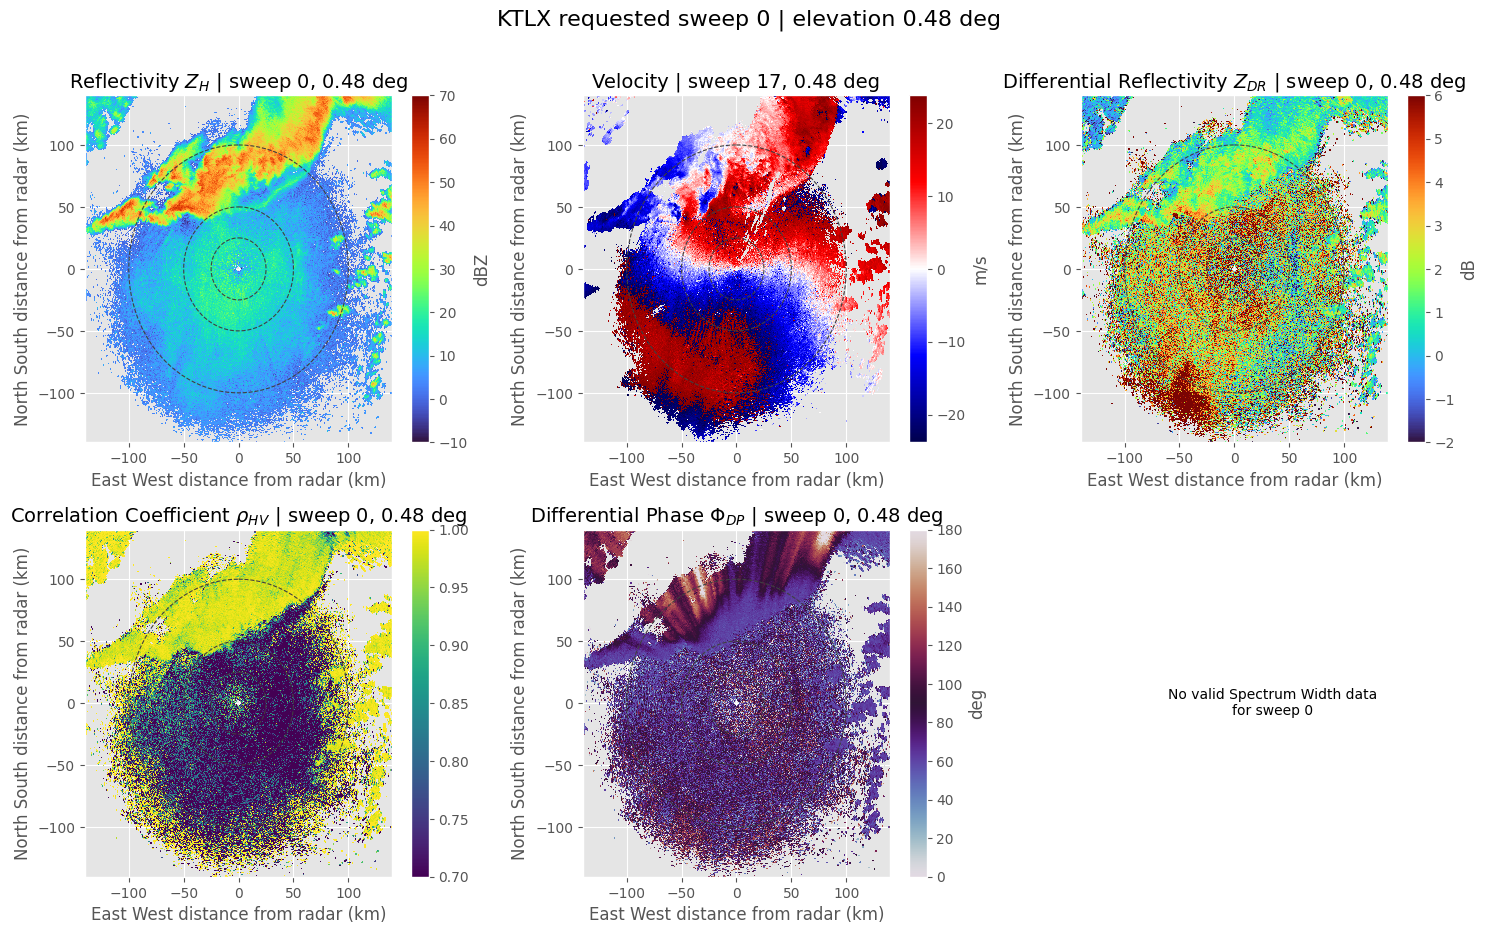

In [ ]:
sweep = 0
plot_dual_pol_fields(radar, sweep=sweep, max_range_km=140);

## Get the Sweep as Arrays

Rows are azimuth rays; columns are range gates.

In [ ]:
def sweep_field(radar, field, sweep=0):
    return radar.get_field(sweep, field).filled(np.nan)


def sweep_azimuths(radar, sweep=0):
    start = radar.sweep_start_ray_index["data"][sweep]
    stop = radar.sweep_end_ray_index["data"][sweep] + 1
    return radar.azimuth["data"][start:stop]


def center_edges(x):
    x = np.asarray(x, dtype=float)
    edges = np.empty(x.size + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges


def plot_polar_sweep(
    ax,
    data,
    ranges_km,
    azimuths_deg,
    title,
    *,
    vmin=None,
    vmax=None,
    cmap="turbo",
    norm=None,
    max_range_km=160,
):
    range_mask = ranges_km <= max_range_km
    r = ranges_km[range_mask]

    order = np.argsort(azimuths_deg)
    az_sorted = azimuths_deg[order]
    data_sorted = data[order][:, range_mask]

    theta_edges = np.deg2rad(center_edges(az_sorted))
    range_edges = center_edges(r)

    kwargs = {"cmap": cmap, "shading": "auto"}
    if norm is None:
        kwargs.update({"vmin": vmin, "vmax": vmax})
    else:
        kwargs["norm"] = norm

    im = ax.pcolormesh(theta_edges, range_edges, data_sorted.T, **kwargs)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_ylim(0, max_range_km)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)
    return im


ranges_km = radar.range["data"] / 1000
azimuths = sweep_azimuths(radar, sweep)
max_plot_range_km = 160

reflectivity_field = resolve_field(radar, "reflectivity")
zdr_field = resolve_field(radar, "differential_reflectivity")
rhohv_field = resolve_field(radar, "cross_correlation_ratio")
phidp_field = resolve_field(radar, "differential_phase")

dbz = sweep_field(radar, reflectivity_field, sweep)
zdr = sweep_field(radar, zdr_field, sweep)
rhohv = sweep_field(radar, rhohv_field, sweep)
phidp = sweep_field(radar, phidp_field, sweep)

print(dbz.shape)
print(f"Fields: {reflectivity_field}, {zdr_field}, {rhohv_field}, {phidp_field}")
print(f"Range gates: {ranges_km[0]:.2f} to {ranges_km[-1]:.1f} km")
print(f"Azimuth rays: {azimuths.min():.1f} to {azimuths.max():.1f} deg")


(720, 1832)
Fields: reflectivity, differential_reflectivity, cross_correlation_ratio, differential_phase
Range gates: 2.12 to 459.9 km
Azimuth rays: 0.2 to 359.8 deg


## Simple rhoHV Filter

$\sigma_{hv}$ is useful because meteorological echoes tend to be highly correlated between H and V.

This is not a complete quality-control algorithm; it's just a compact way to see how a dual-pol variable helps remove obvious noisy or non-meteorological gates.

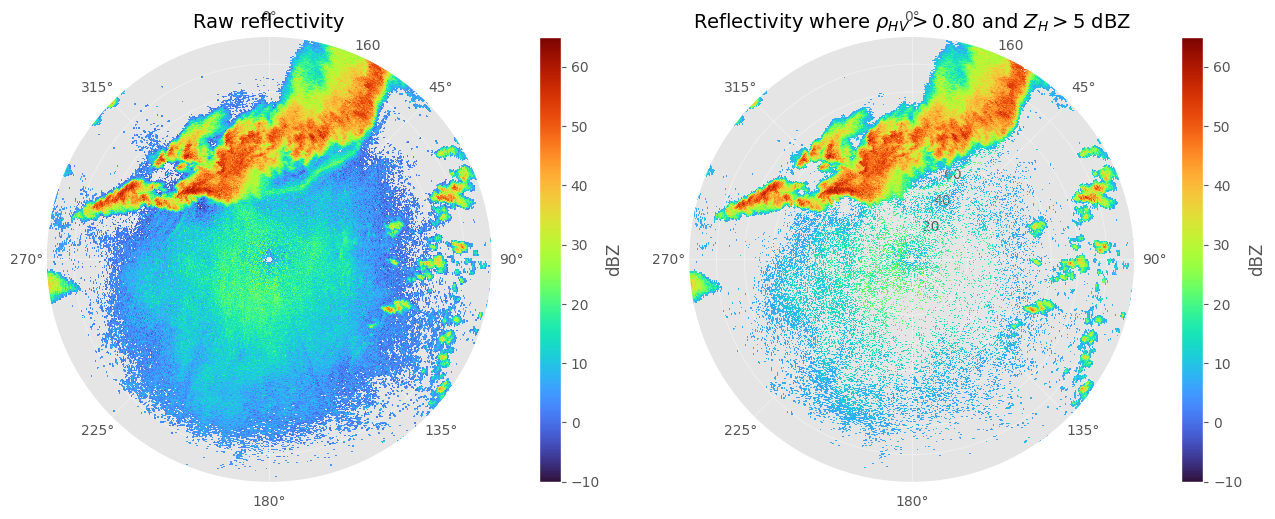

In [ ]:
good_gate = np.isfinite(dbz) & np.isfinite(rhohv) & (dbz > 5) & (rhohv > 0.80)

dbz_filtered = np.where(good_gate, dbz, np.nan)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    subplot_kw={"projection": "polar"},
)

for ax, data, title in zip(
    axes,
    [dbz, dbz_filtered],
    ["Raw reflectivity", "Reflectivity where $\\rho_{HV} > 0.80$ and $Z_H > 5$ dBZ"],
):
    im = plot_polar_sweep(
        ax,
        data,
        ranges_km,
        azimuths,
        title,
        vmin=-10,
        vmax=65,
        cmap="turbo",
        max_range_km=max_plot_range_km,
    )
    fig.colorbar(im, ax=ax, label="dBZ", shrink=0.78, pad=0.08)

plt.tight_layout()

## Estimate KDP from PhiDP

KDP is the range derivative of differential phase.

\begin{equation}
    \Large K_{DP} = \frac{1}{2}\frac{d\Phi_{DP}}{dr}
\end{equation}

The factor of 1/2 is there because the measured phase is accumulated on the two-way path.

Raw PhiDP is noisy, wrapped, and often sparse. If we interpolate across every missing gate, a few isolated noisy gates turn into radial streaks. This simple estimator only processes contiguous weather segments:

- use a stricter weather mask than the reflectivity example
- skip the first 20 km, where phase is often especially noisy
- close only small gaps inside each ray
- unwrap PhiDP inside each segment
- smooth along range
- differentiate only inside the segment


In [ ]:
def close_small_gaps_1d(mask, max_gap=8):
    mask = np.asarray(mask, dtype=bool)
    closed = mask.copy()

    padded = np.r_[False, mask, False].astype(int)
    changes = np.diff(padded)
    starts = np.where(changes == 1)[0]
    stops = np.where(changes == -1)[0]

    for left_stop, right_start in zip(stops[:-1], starts[1:]):
        if right_start - left_stop <= max_gap:
            closed[left_stop:right_start] = True

    return closed


def true_runs(mask, min_length=24):
    padded = np.r_[False, mask, False].astype(int)
    changes = np.diff(padded)
    starts = np.where(changes == 1)[0]
    stops = np.where(changes == -1)[0]

    return [
        (int(start), int(stop))
        for start, stop in zip(starts, stops)
        if stop - start >= min_length
    ]


def smooth_1d(y, width=21):
    if width <= 1:
        return y

    if width % 2 == 0:
        width += 1

    pad = width // 2
    kernel = np.ones(width) / width
    return np.convolve(np.pad(y, (pad, pad), mode="edge"), kernel, mode="valid")


def estimate_kdp_segments(
    phidp_deg,
    ranges_km,
    valid_mask=None,
    smooth_gates=21,
    min_segment_gates=24,
    max_gap_gates=8,
):
    phi = np.asarray(phidp_deg, dtype=float)

    if valid_mask is None:
        valid_mask = np.isfinite(phi)

    phi_smooth = np.full(phi.shape, np.nan)
    kdp = np.full(phi.shape, np.nan)
    used_gate = np.zeros(phi.shape, dtype=bool)
    trim = max(1, smooth_gates // 2)

    for row_idx in range(phi.shape[0]):
        row_valid = valid_mask[row_idx] & np.isfinite(phi[row_idx])
        row_closed = close_small_gaps_1d(row_valid, max_gap=max_gap_gates)

        for start, stop in true_runs(row_closed, min_length=min_segment_gates):
            segment_valid = row_valid[start:stop]

            if segment_valid.sum() < max(6, min_segment_gates // 2):
                continue

            x = np.arange(stop - start)
            y = phi[row_idx, start:stop]
            good = segment_valid & np.isfinite(y)

            if good.sum() < 6:
                continue

            y_filled = np.interp(x, x[good], y[good])

            # NEXRAD PhiDP is angular; unwrap inside the weather segment only.
            y_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(y_filled)))
            y_smooth = smooth_1d(y_unwrapped, width=smooth_gates)

            segment_kdp = 0.5 * np.gradient(y_smooth, ranges_km[start:stop])
            keep = row_closed[start:stop].copy()
            keep[:trim] = False
            keep[-trim:] = False

            smooth_view = phi_smooth[row_idx, start:stop]
            kdp_view = kdp[row_idx, start:stop]
            used_view = used_gate[row_idx, start:stop]

            smooth_view[keep] = y_smooth[keep]
            kdp_view[keep] = segment_kdp[keep]
            used_view[keep] = True

    return kdp, phi_smooth, used_gate


kdp_gate = (
    np.isfinite(dbz)
    & np.isfinite(rhohv)
    & np.isfinite(phidp)
    & (dbz > 10)
    & (rhohv > 0.90)
    & (ranges_km[None, :] > 20)
    & (ranges_km[None, :] < max_plot_range_km)
)

kdp_est, phidp_smooth, kdp_used_gate = estimate_kdp_segments(
    phidp,
    ranges_km,
    valid_mask=kdp_gate,
    smooth_gates=21,
    min_segment_gates=24,
    max_gap_gates=8,
)

print(f"KDP input gates: {kdp_gate.sum():,}")
print(f"KDP output gates: {np.isfinite(kdp_est).sum():,}")


KDP input gates: 61,563
KDP output gates: 49,780


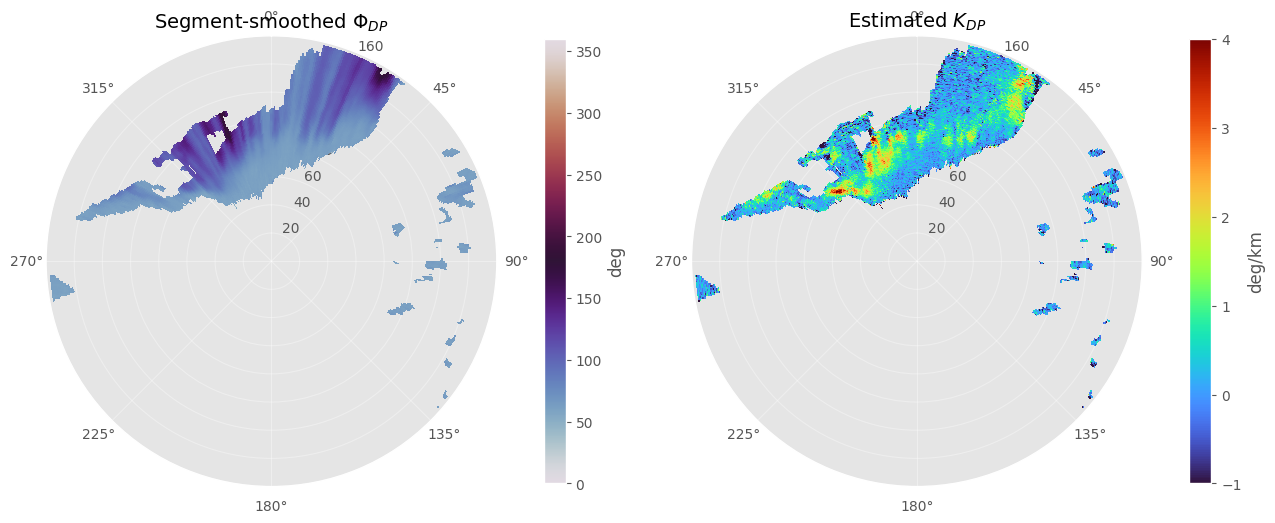

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    subplot_kw={"projection": "polar"},
)

plot_settings = [
    (phidp_smooth, "Segment-smoothed $\\Phi_{DP}$", 0, 360, "twilight", "deg"),
    (kdp_est, "Estimated $K_{DP}$", -1, 4, "turbo", "deg/km"),
]

for ax, (data, title, vmin, vmax, cmap, units) in zip(axes, plot_settings):
    im = plot_polar_sweep(
        ax,
        data,
        ranges_km,
        azimuths,
        title,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        max_range_km=max_plot_range_km,
    )
    fig.colorbar(im, ax=ax, label=units, shrink=0.78, pad=0.08)

plt.tight_layout()


## One Ray: Why KDP Peaks in Heavy Rain

PhiDP is accumulated along the path. KDP is local slope.

That means a broad ramp in PhiDP turns into a local KDP maximum where the rain shaft is strongest.

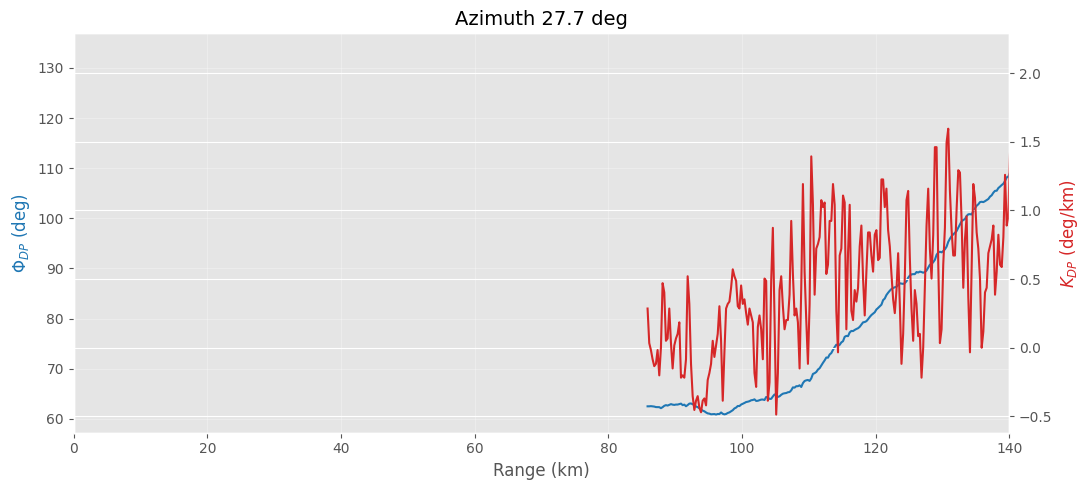

In [ ]:
ray_idx = np.nanargmax(np.nanmean(np.where(good_gate, dbz, np.nan), axis=1))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(ranges_km, phidp_smooth[ray_idx], color="tab:blue", label="$\\Phi_{DP}$")
ax2.plot(ranges_km, kdp_est[ray_idx], color="tab:red", label="$K_{DP}$")

ax1.set_xlim(0, 140)
ax1.set_xlabel("Range (km)")
ax1.set_ylabel("$\\Phi_{DP}$ (deg)", color="tab:blue")
ax2.set_ylabel("$K_{DP}$ (deg/km)", color="tab:red")
ax1.set_title(f"Azimuth {azimuths[ray_idx]:.1f} deg")

ax1.grid(True, alpha=0.3)
plt.tight_layout()

## Rough Rain-Rate Estimates

Reflectivity-only rainfall estimation assumes a fixed relationship between returned power and rain rate:

\begin{equation}
    \Large Z = a R^b
\end{equation}

Dual-pol gives better options because ZDR says something about drop size, and KDP says something about differential phase accumulation through liquid water.

These formulas are intentionally simple and should be treated as educational estimates, not operational QPE.

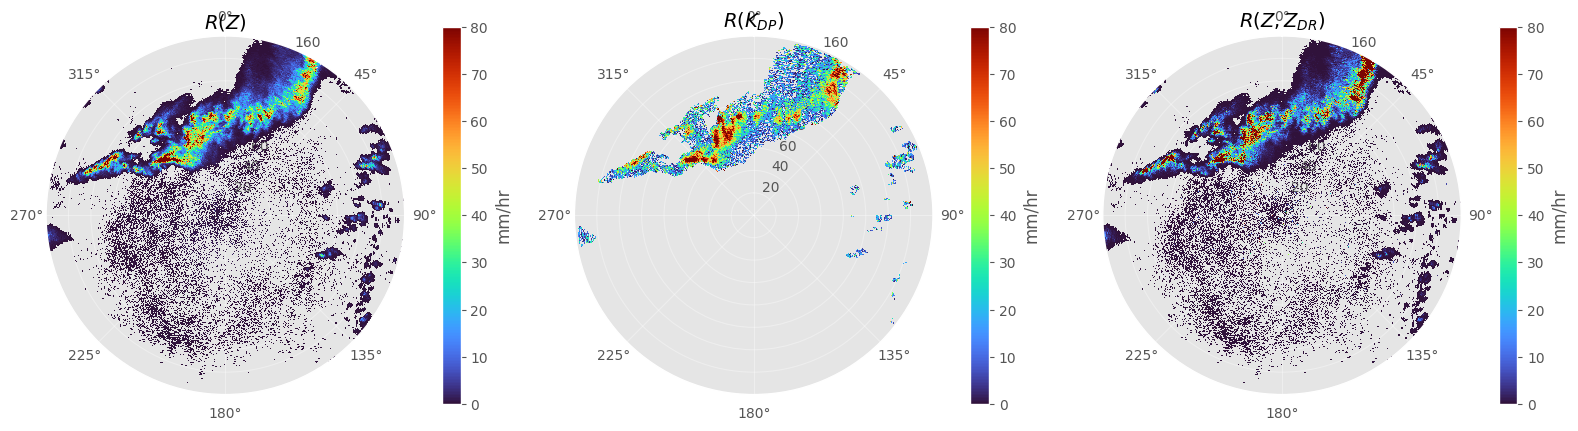

In [ ]:
def rain_rate_from_z(dbz, a=200, b=1.6):
    z_lin = 10 ** (dbz / 10)
    return (z_lin / a) ** (1 / b)


def rain_rate_from_kdp(kdp):
    kdp_pos = np.where(kdp > 0, kdp, np.nan)
    return 40.6 * kdp_pos**0.85


def rain_rate_from_z_zdr(dbz, zdr_db):
    z_lin = 10 ** (dbz / 10)
    zdr_lin = 10 ** (zdr_db / 10)
    return 0.0067 * z_lin**0.927 * zdr_lin**-3.43


rr_z = np.where(good_gate, rain_rate_from_z(dbz), np.nan)
rr_kdp = np.where(good_gate, rain_rate_from_kdp(kdp_est), np.nan)
rr_zzdr = np.where(good_gate, rain_rate_from_z_zdr(dbz, zdr), np.nan)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.4),
    subplot_kw={"projection": "polar"},
)

for ax, data, title in zip(
    axes,
    [rr_z, rr_kdp, rr_zzdr],
    ["$R(Z)$", "$R(K_{DP})$", "$R(Z, Z_{DR})$"],
):
    im = plot_polar_sweep(
        ax,
        data,
        ranges_km,
        azimuths,
        title,
        vmin=0,
        vmax=80,
        cmap="turbo",
        max_range_km=max_plot_range_km,
    )
    fig.colorbar(im, ax=ax, label="mm/hr", shrink=0.74, pad=0.08)

plt.tight_layout()

## Toy Hydrometeor / Target-Type Classifier

Real hydrometeor classification normally uses fuzzy logic, temperature, height, quality control, and tuned membership functions.

This toy classifier is just meant to show why one variable is not enough:

- reflectivity gives intensity
- ZDR gives effective shape/drop-size information
- rhoHV gives consistency
- KDP helps identify liquid-water loading

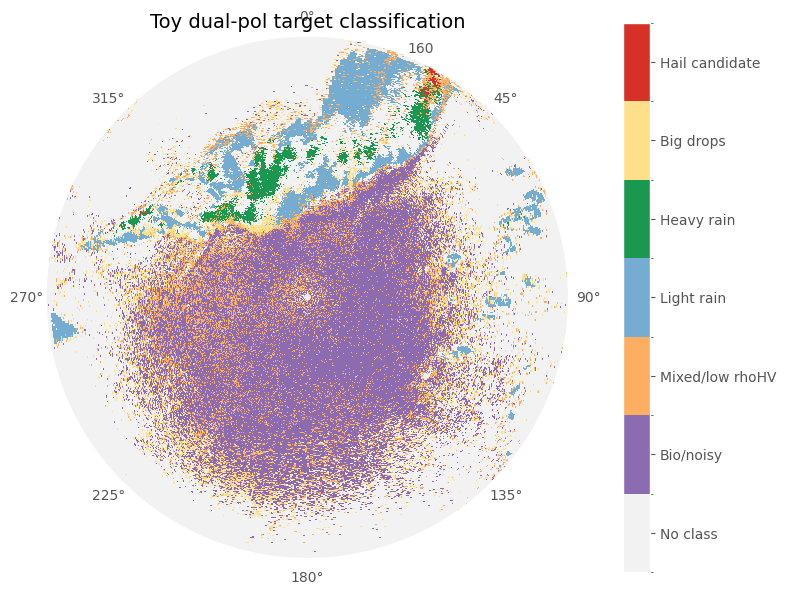

In [ ]:
def simple_dual_pol_classifier(dbz, zdr, rhohv, kdp):
    cls = np.zeros(dbz.shape, dtype=int)
    valid = np.isfinite(dbz) & np.isfinite(zdr) & np.isfinite(rhohv)

    # 0 = no data / not classified
    biological = valid & (rhohv < 0.80) & (dbz < 35)
    mixed = valid & (rhohv >= 0.80) & (rhohv < 0.95)
    light_rain = valid & (rhohv >= 0.95) & (dbz >= 5) & (dbz < 35) & (kdp < 1.0)
    heavy_rain = valid & (rhohv >= 0.95) & (dbz >= 35) & (kdp >= 1.0)
    big_drops = valid & (rhohv >= 0.95) & (zdr >= 2.5) & (dbz < 45)
    hail_candidate = valid & (dbz >= 50) & (rhohv < 0.97) & (zdr < 1.5)

    cls[biological] = 1
    cls[mixed] = 2
    cls[light_rain] = 3
    cls[heavy_rain] = 4
    cls[big_drops] = 5
    cls[hail_candidate] = 6

    return cls


classes = simple_dual_pol_classifier(dbz, zdr, rhohv, kdp_est)

class_names = [
    "No class",
    "Bio/noisy",
    "Mixed/low rhoHV",
    "Light rain",
    "Heavy rain",
    "Big drops",
    "Hail candidate",
]

class_colors = [
    "#f2f2f2",
    "#8c6bb1",
    "#fdae61",
    "#74add1",
    "#1a9850",
    "#fee08b",
    "#d73027",
]

cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(len(class_names) + 1) - 0.5, cmap.N)

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": "polar"})
im = plot_polar_sweep(
    ax,
    classes,
    ranges_km,
    azimuths,
    "Toy dual-pol target classification",
    cmap=cmap,
    norm=norm,
    max_range_km=max_plot_range_km,
)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(class_names)), shrink=0.82, pad=0.08)
cbar.ax.set_yticklabels(class_names)
plt.tight_layout()

## Field Scatterplots

A lot of dual-pol interpretation comes from combinations of variables, not a single map.

These scatterplots are a useful sanity check for whether the classifier thresholds make sense.

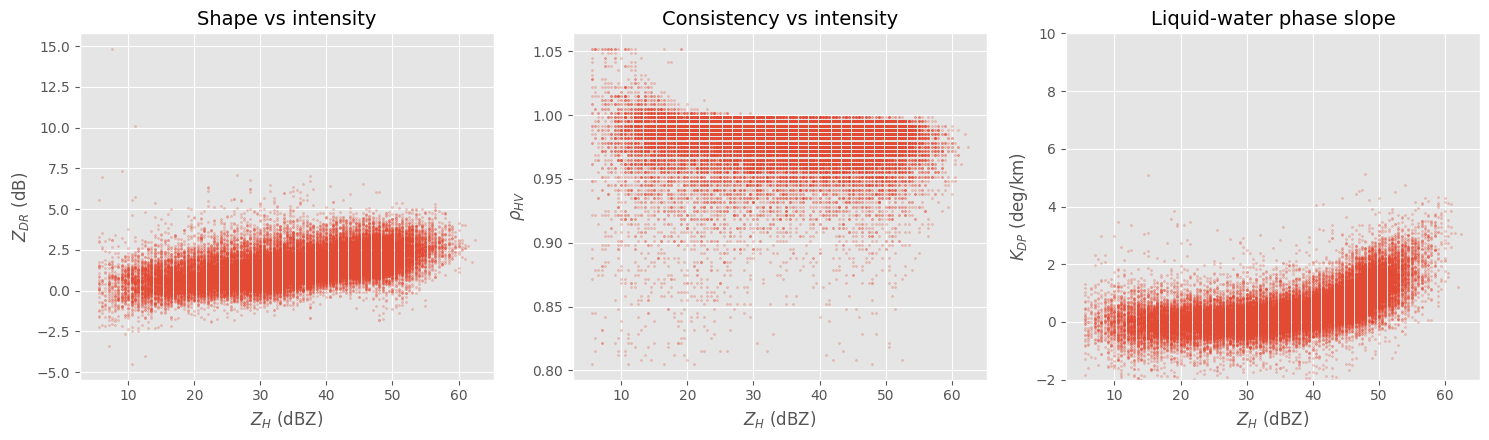

In [ ]:
valid = good_gate & np.isfinite(zdr) & np.isfinite(kdp_est)

sample = np.where(valid.ravel())[0]
if sample.size > 40000:
    rng = np.random.default_rng(0)
    sample = rng.choice(sample, size=40000, replace=False)

dbz_s = dbz.ravel()[sample]
zdr_s = zdr.ravel()[sample]
rho_s = rhohv.ravel()[sample]
kdp_s = kdp_est.ravel()[sample]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(dbz_s, zdr_s, s=2, alpha=0.25)
axes[0].set_xlabel("$Z_H$ (dBZ)")
axes[0].set_ylabel("$Z_{DR}$ (dB)")
axes[0].set_title("Shape vs intensity")

axes[1].scatter(dbz_s, rho_s, s=2, alpha=0.25)
axes[1].set_xlabel("$Z_H$ (dBZ)")
axes[1].set_ylabel("$\\rho_{HV}$")
axes[1].set_title("Consistency vs intensity")

axes[2].scatter(dbz_s, kdp_s, s=2, alpha=0.25)
axes[2].set_xlabel("$Z_H$ (dBZ)")
axes[2].set_ylabel("$K_{DP}$ (deg/km)")
axes[2].set_ylim(-2, 10)
axes[2].set_title("Liquid-water phase slope")

plt.tight_layout()

## Things to Try

- Change `radar_site` and `target_time` to pull a different storm.
- Change `sweep` to compare low-level and higher-elevation scans.
- Change the rhoHV threshold in `good_gate`.
- Increase or decrease `smooth_gates` in `estimate_kdp`.
- Edit the toy classifier thresholds and see which classes are fragile.

The important idea is that dual-pol products are not magic labels. They are extra measurements that make the inverse problem less ambiguous.